# EDA — Clasificación de Objetos Estelares (SDSS)

El dataset contiene **100.000 observaciones** del Sloan Digital Sky Survey (SDSS). Cada objeto fue clasificado en una de tres categorías:
- **GALAXY** — galaxia
- **STAR** — estrella
- **QSO** — quásar (objeto cuasi-estelar)

Las features incluyen coordenadas celestes, magnitudes en cinco filtros fotométricos (u, g, r, i, z) y metadatos del instrumento.

# Descripción de variables del catálogo SDSS

| Variable | Descripción |
|---|---|
| `obj_ID` | Object Identifier. Valor único que identifica el objeto en el catálogo de imágenes usado por el CAS. |
| `alpha` | Ángulo de Ascensión Recta (*Right Ascension*) en la época J2000. |
| `delta` | Ángulo de Declinación (*Declination*) en la época J2000. |
| `u` | Filtro ultravioleta del sistema fotométrico. |
| `g` | Filtro verde del sistema fotométrico. |
| `r` | Filtro rojo del sistema fotométrico. |
| `i` | Filtro infrarrojo cercano del sistema fotométrico. |
| `z` | Filtro infrarrojo del sistema fotométrico. |
| `run_ID` | Número de corrida (*Run Number*) usado para identificar el escaneo específico. |
| `rerun_ID` | Número de reprocesamiento (*Rerun Number*) que indica cómo fue procesada la imagen. |
| `cam_col` | Columna de cámara usada para identificar la línea de escaneo dentro de la corrida. |
| `field_ID` | Número de campo usado para identificar cada campo observado. |
| `spec_obj_ID` | ID único usado para objetos espectroscópicos ópticos. Dos observaciones diferentes con el mismo `spec_obj_ID` deben compartir la misma clase de salida. |
| `class` | Clase del objeto observado: galaxia, estrella o cuásar. |
| `redshift` | Valor de corrimiento al rojo, basado en el aumento de la longitud de onda. |
| `plate` | ID de la placa. Identifica cada placa en SDSS. |
| `MJD` | Fecha Juliana Modificada (*Modified Julian Date*). Se usa para indicar cuándo fue tomada una observación o dato de SDSS. |
| `fiber_ID` | ID de la fibra que dirigió la luz hacia el plano focal en cada observación. |

#### Librerías

In [2]:
import pandas as pd
import numpy as np
from sklearn.feature_selection import mutual_info_classif
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from scipy import stats

sns.set_theme(style="whitegrid", palette="Set2")
plt.rcParams["figure.dpi"] = 120


#### Carga del dataset

In [3]:
df = pd.read_csv("star_classification.csv")
print(f"Shape: {df.shape}")
df.head()

Shape: (100000, 18)


,obj_ID,alpha,delta,u,g,r,i,z,run_ID,rerun_ID,cam_col,field_ID,spec_obj_ID,class,redshift,plate,MJD,fiber_ID
0,1.237661e+18,135.689107,32.494632,23.87882,22.27530,20.39501,19.16573,18.79371,3606,301,2,79,6.543777e+18,GALAXY,0.634794,5812,56354,171
1,1.237665e+18,144.826101,31.274185,24.77759,22.83188,22.58444,21.16812,21.61427,4518,301,5,119,1.176014e+19,GALAXY,0.779136,10445,58158,427
2,1.237661e+18,142.188790,35.582444,25.26307,22.66389,20.60976,19.34857,18.94827,3606,301,2,120,5.152200e+18,GALAXY,0.644195,4576,55592,299
3,1.237663e+18,338.741038,-0.402828,22.13682,23.77656,21.61162,20.50454,19.25010,4192,301,3,214,1.030107e+19,GALAXY,0.932346,9149,58039,775
4,1.237680e+18,345.282593,21.183866,19.43718,17.58028,16.49747,15.97711,15.54461,8102,301,3,137,6.891865e+18,GALAXY,0.116123,6121,56187,842


#### Inspección inicial: tipos y estadísticas

In [4]:
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 18 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   obj_ID       100000 non-null  float64
 1   alpha        100000 non-null  float64
 2   delta        100000 non-null  float64
 3   u            100000 non-null  float64
 4   g            100000 non-null  float64
 5   r            100000 non-null  float64
 6   i            100000 non-null  float64
 7   z            100000 non-null  float64
 8   run_ID       100000 non-null  int64  
 9   rerun_ID     100000 non-null  int64  
 10  cam_col      100000 non-null  int64  
 11  field_ID     100000 non-null  int64  
 12  spec_obj_ID  100000 non-null  float64
 13  class        100000 non-null  object 
 14  redshift     100000 non-null  float64
 15  plate        100000 non-null  int64  
 16  MJD          100000 non-null  int64  
 17  fiber_ID     100000 non-null  int64  
dtypes: float64(10), int64(7),

,obj_ID,alpha,delta,u,g,r,i,z,run_ID,rerun_ID,cam_col,field_ID,spec_obj_ID,redshift,plate,MJD,fiber_ID
count,1.000000e+05,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.0,100000.000000,100000.000000,1.000000e+05,100000.000000,100000.000000,100000.000000,100000.000000
mean,1.237665e+18,177.629117,24.135305,21.980468,20.531387,19.645762,19.084854,18.668810,4481.366060,301.0,3.511610,186.130520,5.783882e+18,0.576661,5137.009660,55588.647500,449.312740
std,8.438560e+12,96.502241,19.644665,31.769291,31.750292,1.854760,1.757895,31.728152,1964.764593,0.0,1.586912,149.011073,3.324016e+18,0.730707,2952.303351,1808.484233,272.498404
min,1.237646e+18,0.005528,-18.785328,-9999.000000,-9999.000000,9.822070,9.469903,-9999.000000,109.000000,301.0,1.000000,11.000000,2.995191e+17,-0.009971,266.000000,51608.000000,1.000000
25%,1.237659e+18,127.518222,5.146771,20.352353,18.965230,18.135828,17.732285,17.460677,3187.000000,301.0,2.000000,82.000000,2.844138e+18,0.054517,2526.000000,54234.000000,221.000000
50%,1.237663e+18,180.900700,23.645922,22.179135,21.099835,20.125290,19.405145,19.004595,4188.000000,301.0,4.000000,146.000000,5.614883e+18,0.424173,4987.000000,55868.500000,433.000000
75%,1.237668e+18,233.895005,39.901550,23.687440,22.123767,21.044785,20.396495,19.921120,5326.000000,301.0,5.000000,241.000000,8.332144e+18,0.704154,7400.250000,56777.000000,645.000000
max,1.237681e+18,359.999810,83.000519,32.781390,31.602240,29.571860,32.141470,29.383740,8162.000000,301.0,6.000000,989.000000,1.412694e+19,7.011245,12547.000000,58932.000000,1000.000000


In [30]:
df.iloc[1]

obj_ID          1237664879951151104.0
alpha                      144.826101
delta                       31.274185
u                            24.77759
g                            22.83188
r                            22.58444
i                            21.16812
z                            21.61427
run_ID                           4518
rerun_ID                          301
cam_col                             5
field_ID                          119
spec_obj_ID    11760142036707334144.0
class                          GALAXY
redshift                     0.779136
plate                           10445
MJD                             58158
fiber_ID                          427
Name: 1, dtype: object

#### Búsqueda de valores nulos

In [5]:
df.isnull().sum()

obj_ID         0
alpha          0
delta          0
u              0
g              0
r              0
i              0
z              0
run_ID         0
rerun_ID       0
cam_col        0
field_ID       0
spec_obj_ID    0
class          0
redshift       0
plate          0
MJD            0
fiber_ID       0
dtype: int64

#### Distribución de la variable objetivo

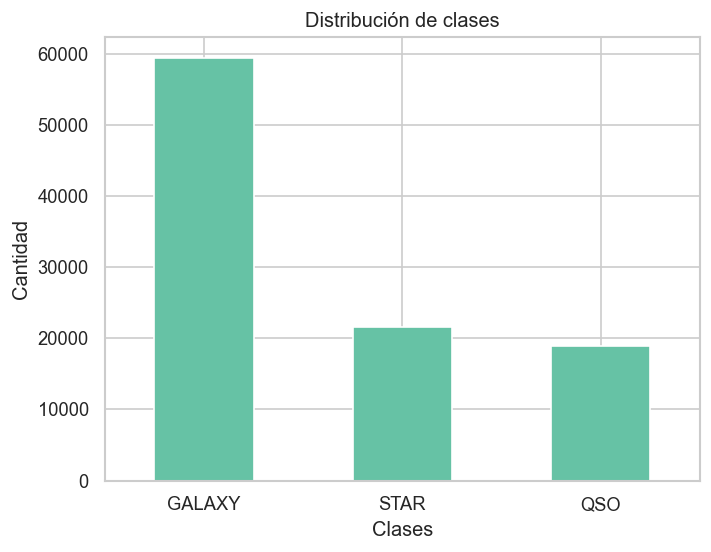

In [6]:
df.value_counts('class')

df['class'].value_counts().plot(kind='bar')
plt.title('Distribución de clases')
plt.ylabel('Cantidad')
plt.xlabel('Clases')
plt.xticks(rotation=0)
plt.show()

## ¿Qué variables sirven para predecir `class`?

No todas las columnas son features físicas útiles. Las separamos en tres grupos:

- **Identificadores** (`obj_ID`, `spec_obj_ID`): valores casi únicos por fila. No tienen valor predictivo y pueden generar *data leakage* — los descartamos.
- **Metadatos del instrumento** (`run_ID`, `rerun_ID`, `cam_col`, `field_ID`, `plate`, `MJD`, `fiber_ID`): describen *cómo/cuándo* se tomó la observación, no el objeto en sí. `rerun_ID` además es **constante** (1 solo valor) → aporta cero información. Hay que tratarlos con cuidado porque algunos (`plate`, `MJD`, `fiber_ID`) están atados a la medición espectroscópica que definió la clase.
- **Features físicas**: coordenadas (`alpha`, `delta`), magnitudes fotométricas (`u`, `g`, `r`, `i`, `z`) y `redshift`. Son las candidatas reales.

A continuación comparamos cada feature contra la variable objetivo para ver cuáles separan las clases.

#### Cardinalidad de cada columna

In [8]:
df.nunique()

obj_ID          78053
alpha           99999
delta           99999
u               93748
g               92651
r               91901
i               92019
z               92007
run_ID            430
rerun_ID            1
cam_col             6
field_ID          856
spec_obj_ID    100000
class               3
redshift        99295
plate            6284
MJD              2180
fiber_ID         1000
dtype: int64

#### Análisis de los identificadores

In [9]:
df.groupby('class')['obj_ID'].describe()

,count,mean,std,min,25%,50%,75%,max
class,,,,,,,,
GALAXY,59445.0,1.237665e+18,8.399536e+12,1.237646e+18,1.237659e+18,1.237664e+18,1.237668e+18,1.237681e+18
QSO,18961.0,1.237665e+18,8.659960e+12,1.237646e+18,1.237659e+18,1.237662e+18,1.237671e+18,1.237681e+18
STAR,21594.0,1.237664e+18,8.300272e+12,1.237646e+18,1.237658e+18,1.237663e+18,1.237669e+18,1.237681e+18


#### Histogramas de todas las variables

array([[<Axes: title={'center': 'obj_ID'}>,
        <Axes: title={'center': 'alpha'}>,
        <Axes: title={'center': 'delta'}>, <Axes: title={'center': 'u'}>],
       [<Axes: title={'center': 'g'}>, <Axes: title={'center': 'r'}>,
        <Axes: title={'center': 'i'}>, <Axes: title={'center': 'z'}>],
       [<Axes: title={'center': 'run_ID'}>,
        <Axes: title={'center': 'rerun_ID'}>,
        <Axes: title={'center': 'cam_col'}>,
        <Axes: title={'center': 'field_ID'}>],
       [<Axes: title={'center': 'spec_obj_ID'}>,
        <Axes: title={'center': 'redshift'}>,
        <Axes: title={'center': 'plate'}>,
        <Axes: title={'center': 'MJD'}>],
       [<Axes: title={'center': 'fiber_ID'}>, <Axes: >, <Axes: >,
        <Axes: >]], dtype=object)

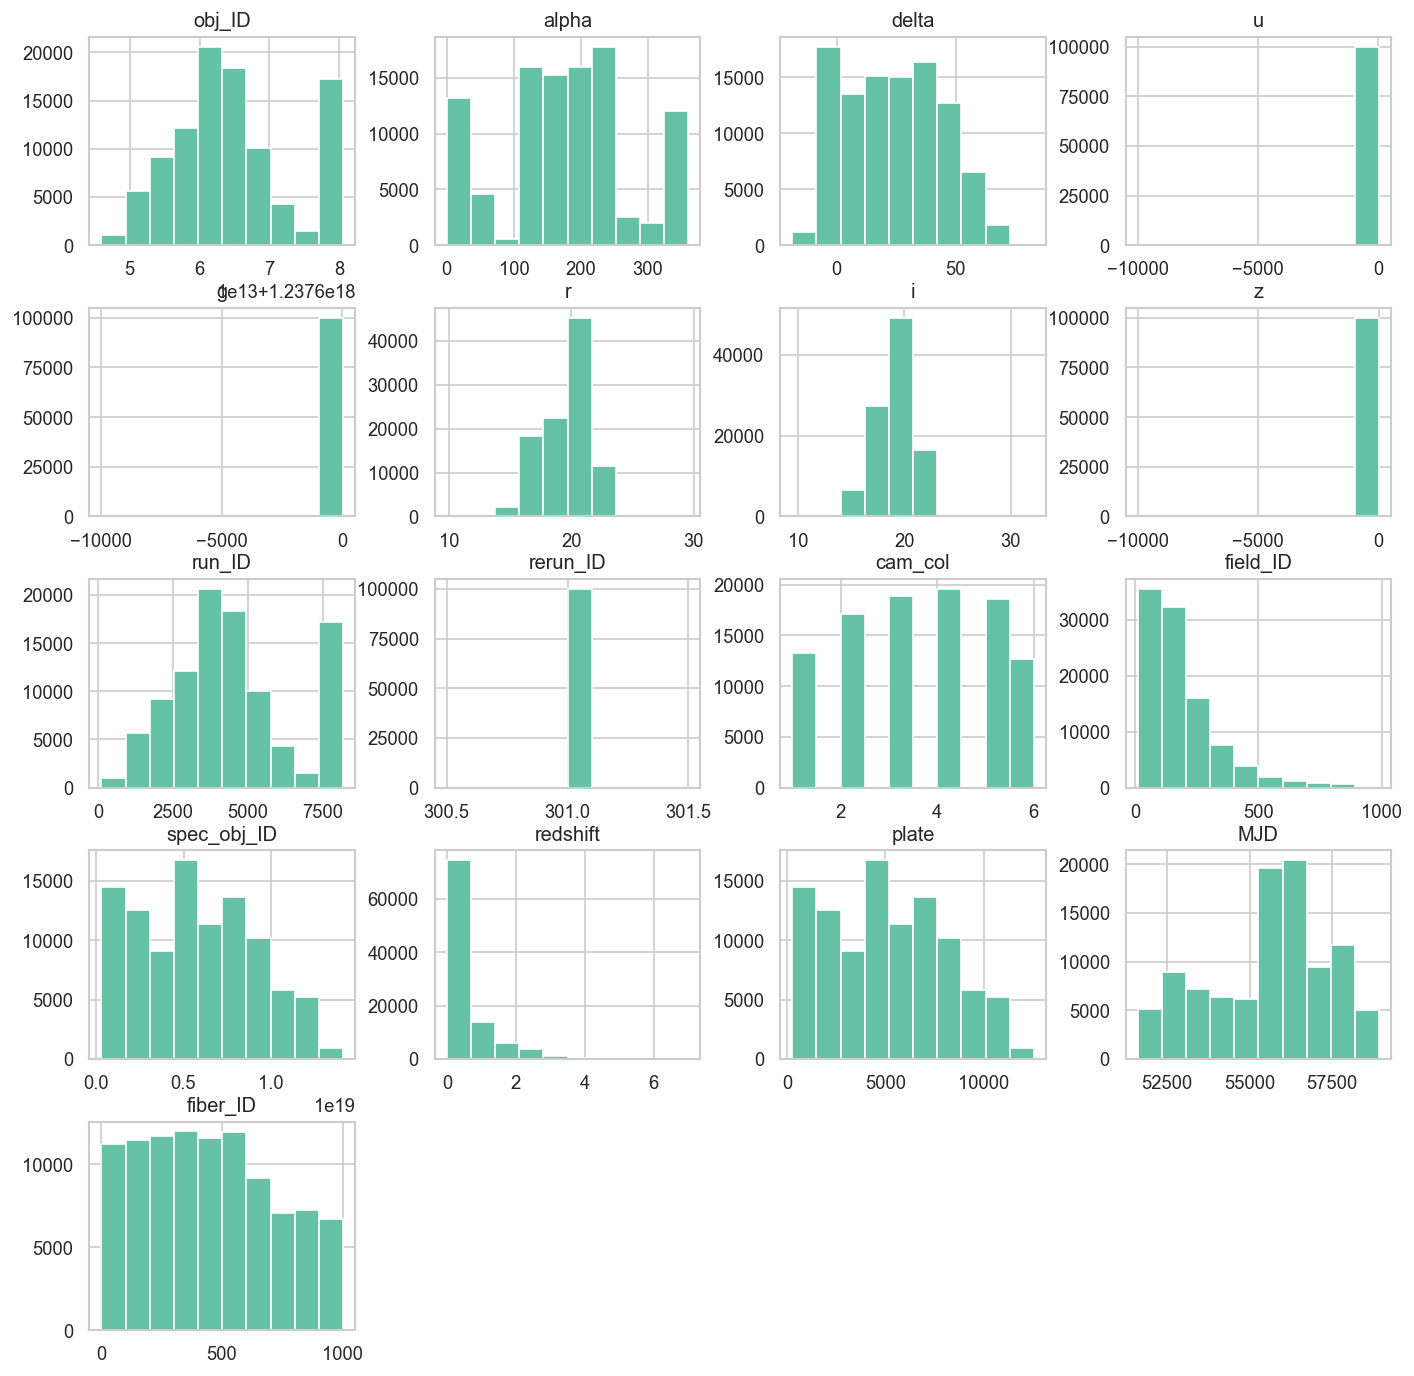

In [10]:
df.hist(bins = 10, figsize=(14,14))

#### Detección del valor centinela -9999

In [11]:
(df[['u', 'g', 'z']] == -9999).any(axis = 1).sum()

1

Hay un único valor que se sale del rango. Vamos a eliminarlo porque es sólo uno de 100mil.

In [12]:
mask = (df[['u', 'g', 'z']] == -9999).any(axis = 1)
df = df[~mask]

#### Histogramas después de eliminar el valor inválido

array([[<Axes: title={'center': 'obj_ID'}>,
        <Axes: title={'center': 'alpha'}>,
        <Axes: title={'center': 'delta'}>, <Axes: title={'center': 'u'}>],
       [<Axes: title={'center': 'g'}>, <Axes: title={'center': 'r'}>,
        <Axes: title={'center': 'i'}>, <Axes: title={'center': 'z'}>],
       [<Axes: title={'center': 'run_ID'}>,
        <Axes: title={'center': 'rerun_ID'}>,
        <Axes: title={'center': 'cam_col'}>,
        <Axes: title={'center': 'field_ID'}>],
       [<Axes: title={'center': 'spec_obj_ID'}>,
        <Axes: title={'center': 'redshift'}>,
        <Axes: title={'center': 'plate'}>,
        <Axes: title={'center': 'MJD'}>],
       [<Axes: title={'center': 'fiber_ID'}>, <Axes: >, <Axes: >,
        <Axes: >]], dtype=object)

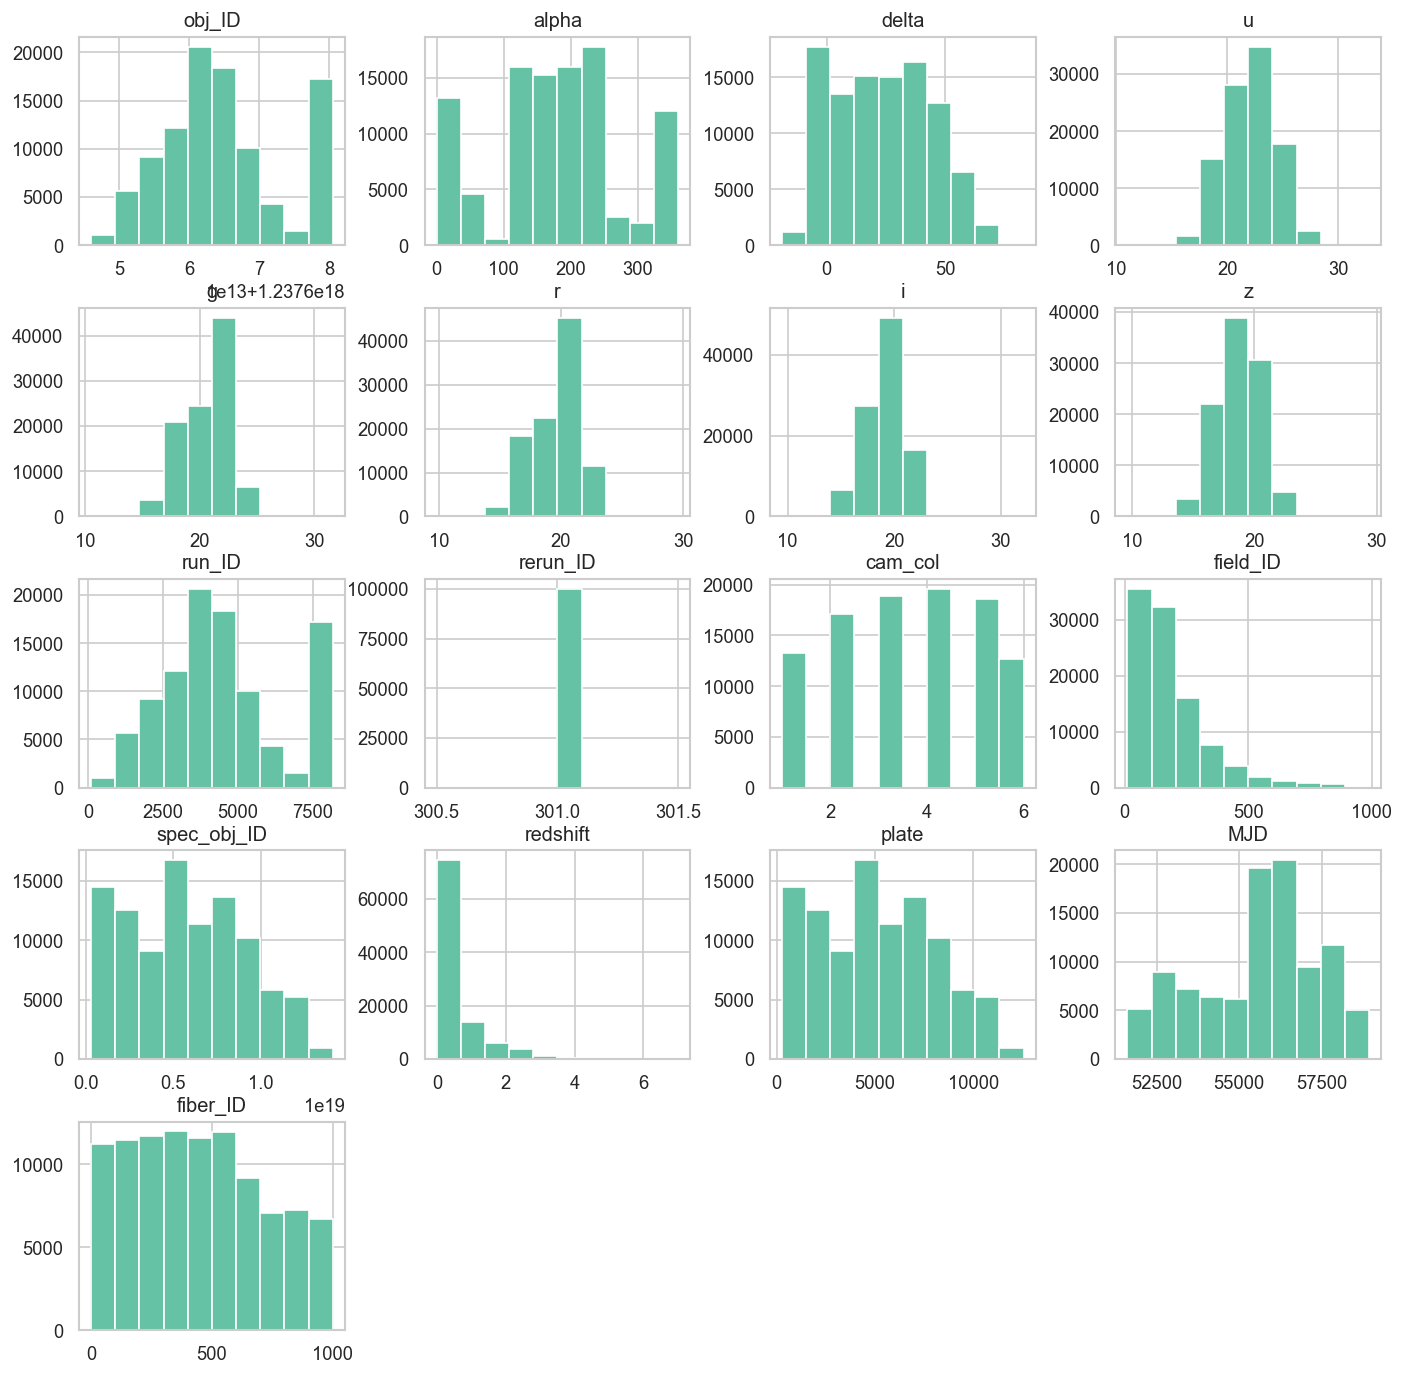

In [13]:
df.hist(bins = 10, figsize=(14,14))


¿Existirá alguna relación entre la magnitud del brillo y la clase de objeto?

In [14]:
# me pregunto si existe alguna relación entre la clase y la magnitud del brillo
df.groupby('class')[['u', 'g', 'r', 'i', 'z']].mean()

,u,g,r,i,z
class,,,,,
GALAXY,22.587379,20.906101,19.587552,18.851990,18.449156
QSO,21.547619,20.926193,20.624089,20.431173,20.266732
STAR,21.153830,19.617142,18.947005,18.543760,18.334295


#### Distribución del brillo (r) por clase

<Axes: xlabel='class', ylabel='r'>

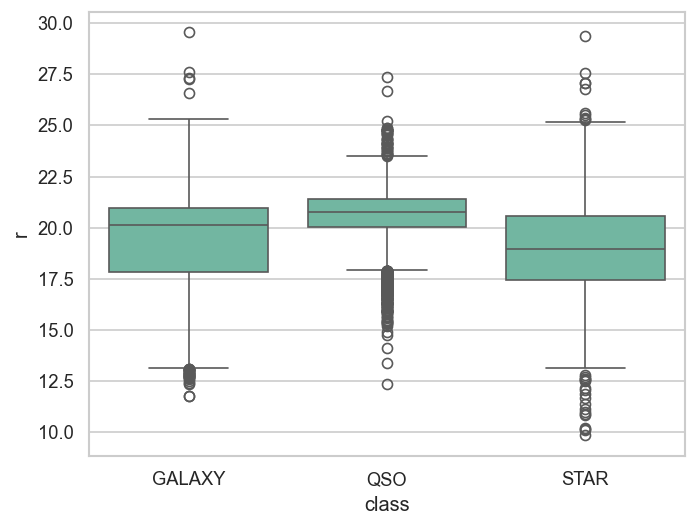

In [15]:
sns.boxplot(data = df, x = 'class', y = 'r')

#### Índice de color (u − g) por clase

<Axes: xlabel='class', ylabel='None'>

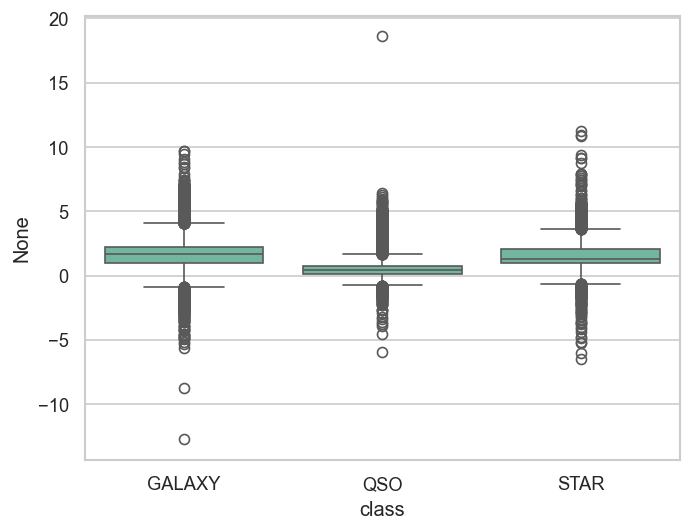

In [16]:
sns.boxplot(data=df, x = 'class', y = df['u'] - df['g'])

#### Redshift por clase

<Axes: xlabel='class', ylabel='redshift'>

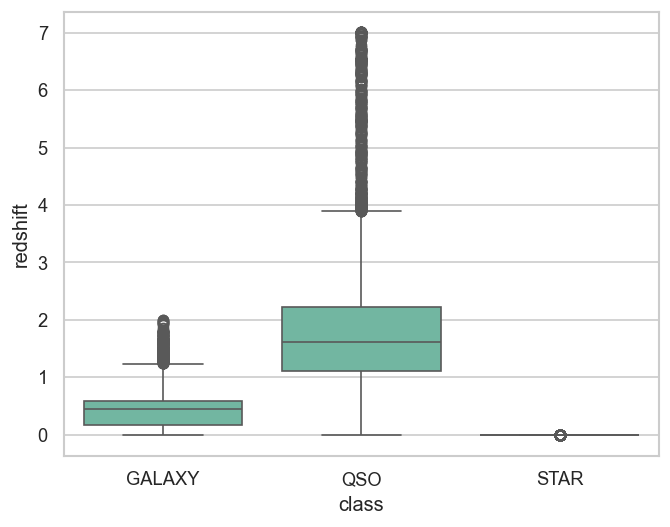

In [17]:
sns.boxplot(data = df, x = 'class', y = df['redshift'])


#### Estadísticas de redshift por clase

In [18]:
df.groupby('class')['redshift'].describe()

,count,mean,std,min,25%,50%,75%,max
class,,,,,,,,
GALAXY,59445.0,0.421596,0.264858,-0.009971,0.164527,0.456274,0.594699,1.995524
QSO,18961.0,1.719676,0.913954,0.000461,1.106605,1.617232,2.220279,7.011245
STAR,21593.0,-0.000115,0.000465,-0.004136,-0.000295,-0.000076,0.000075,0.004153


#### ¿Qué tan lejos están? El redshift en términos humanos

Las magnitudes miden *brillo*, no distancia. La variable que funciona como **regla de distancia** es `redshift`: la expansión del universo "estira" la luz de los objetos lejanos hacia el rojo. Usamos el modelo cosmológico estándar (**Planck18**) para traducir cada redshift al **tiempo que viajó su luz** hasta nosotros, es decir, *cuán atrás en el tiempo* lo estamos viendo.

In [28]:
from astropy.cosmology import Planck18 as cosmo

edad_universo = cosmo.age(0).value  # edad actual del universo (~13.8 mil M de años)
print(f"Edad actual del universo: {edad_universo:.1f} mil millones de años\n")

for clase in ['STAR', 'GALAXY', 'QSO']:
    z = df.loc[df['class'] == clase, 'redshift'].median()
    z = max(z, 1e-6)                      # las estrellas tienen z ~ 0
    t_luz = cosmo.lookback_time(z).value  # cuánto viajó la luz hasta nosotros
    edad_obj = edad_universo - t_luz      # edad del universo cuando salió esa luz
    print(f"{clase:7} | z mediano = {z:6.3f} | la luz viajó {t_luz:5.2f} mil M de años "
          f"| lo vemos como era cuando el universo tenía {edad_obj:5.2f} mil M de años")

z_max = df['redshift'].max()
t_max = cosmo.lookback_time(z_max).value
print(f"\nObjeto más lejano del dataset: z = {z_max:.2f}  ->  luz de hace {t_max:.2f} mil M de años "
      f"(el universo tenía apenas {edad_universo - t_max:.2f} mil M de años)")

Edad actual del universo: 13.8 mil millones de años

STAR    | z mediano =  0.000 | la luz viajó  0.00 mil M de años | lo vemos como era cuando el universo tenía 13.79 mil M de años
GALAXY  | z mediano =  0.456 | la luz viajó  4.87 mil M de años | lo vemos como era cuando el universo tenía  8.92 mil M de años
QSO     | z mediano =  1.617 | la luz viajó  9.79 mil M de años | lo vemos como era cuando el universo tenía  4.00 mil M de años

Objeto más lejano del dataset: z = 7.01  ->  luz de hace 13.03 mil M de años (el universo tenía apenas 0.76 mil M de años)


**Intuición de los resultados:**

- **STAR** (z ≈ 0): están en nuestra propia galaxia; su luz es prácticamente "del presente".
- **GALAXY** (z ≈ 0.46): las vemos como eran hace ~4.9 mil M de años, cuando el Sol y la Tierra recién se formaban.
- **QSO** (z ≈ 1.62): luz de hace ~9.8 mil M de años, cuando el universo tenía apenas ~4 mil M de años.
- El quásar más lejano (z ≈ 7) nos muestra el universo con solo ~0.76 mil M de años de edad: casi el amanecer cósmico.

Esto explica *por qué* el redshift separa tan bien las clases: no es un número arbitrario, sino la **distancia y época** de cada tipo de objeto.

#### Correlación entre magnitudes y redshift

<Axes: >

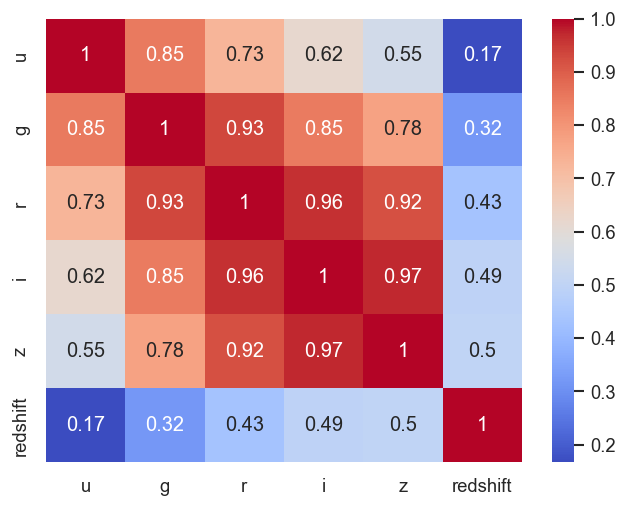

In [19]:
# Quiero conocer cómo se relacionan entre sí las variables, ¿qué pasa con las magnitudes u g r i z y redshift?
sns.heatmap(df[['u', 'g', 'r', 'i', 'z', 'redshift']].corr(), annot=True, cmap="coolwarm")

#### Información mutua de cada feature con la clase

In [20]:
cols_fuera = ['obj_ID', 'spec_obj_ID', 'rerun_ID', 'run_ID', 'cam_col',
                'field_ID', 'plate', 'MJD', 'fiber_ID', 'class']
X = df.drop(columns=cols_fuera)
y = df['class'].astype('category').cat.codes
mi = mutual_info_classif(X, y, random_state=0)
ranking = pd.Series(mi, index=X.columns).sort_values(ascending=False)
print(ranking)

redshift    0.801815
z           0.145354
g           0.120641
i           0.109435
u           0.100333
r           0.075563
delta       0.044373
alpha       0.040454
dtype: float64


#### Ranking de importancia (gráfico)

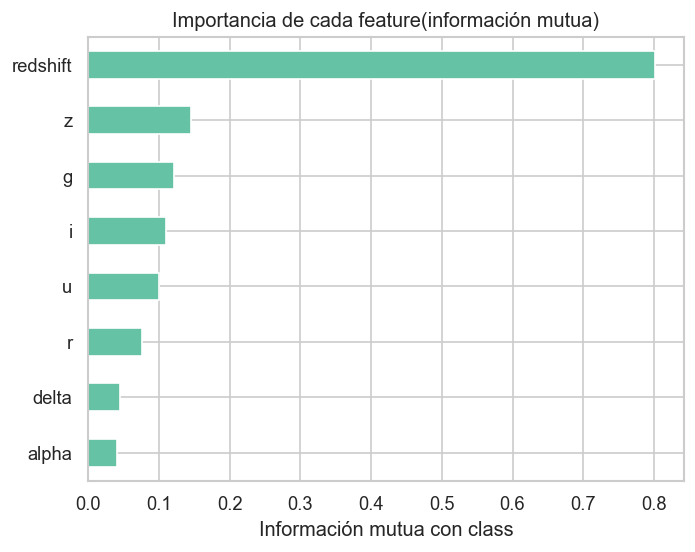

In [21]:
ranking.sort_values().plot(kind='barh', title='Importancia de cada feature(información mutua)')
plt.xlabel('Información mutua con class')
plt.show()

#### Separación de clases: redshift vs. g

<Axes: xlabel='redshift', ylabel='g'>

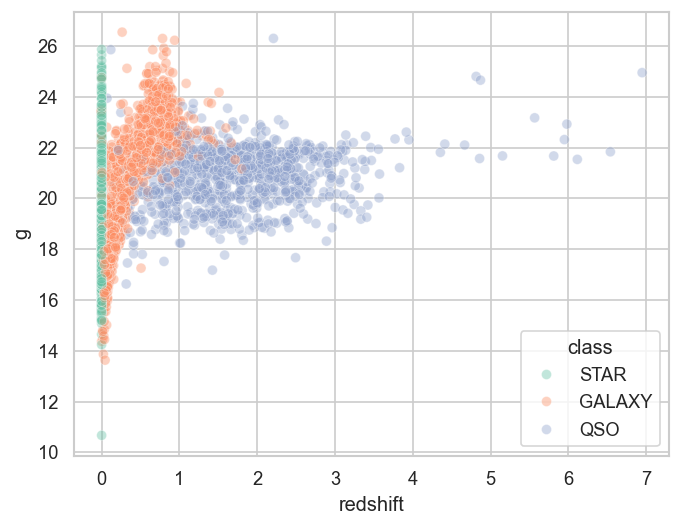

In [22]:
sns.scatterplot(data=df.sample(5000), x='redshift', y='g', hue='class', alpha=0.4)


#### Detección de outliers en redshift (método IQR)

In [23]:
Q1 = df['redshift'].quantile(0.25)
Q3 = df['redshift'].quantile(0.75)
IQR = Q3 - Q1
lim_inf = Q1 - 1.5 * IQR
lim_sup = Q3 + 1.5 * IQR
outliers = df[(df['redshift'] < lim_inf) | (df['redshift'] > lim_sup)]
print(f"Outliers en redshift: {len(outliers)}")

Outliers en redshift: 8989


### Esos no son outliers, en realidad son QSO. Si los elimino estaría quitando datos valiosos.
El método IQR marca ~9% como outliers en redshift, pero no son errores: son quásares con corrimiento al rojo alto, datos físicamente válidos. No se eliminan. A diferencia del -9999 (que sí era un error de medición), estos outliers son la señal, no ruido. El IQR no aplica bien a distribuciones multimodales como esta.

### Quiero saber si hay duplicados

In [25]:
df.duplicated().sum()

0

#### Proporción de cada clase (desbalance)

In [27]:
df['class'].value_counts(normalize=True)*100

class
GALAXY    59.445594
STAR      21.593216
QSO       18.961190
Name: proportion, dtype: float64

  ## Conclusiones del EDA

  **Calidad de los datos**
  - Sin valores nulos y sin filas duplicadas (0).
  - Se detectó y eliminó 1 fila con valor centinela `-9999` en `u`, `g`, `z` (error de medición, no dato real).

  **Variable objetivo (`class`)**
  - Tres clases con desbalance moderado: GALAXY (~59%), STAR (~21%), QSO (~19%).
  - → En el modelado conviene usar `stratify` y no evaluar solo con accuracy.

  **Features según su utilidad**
  - **`redshift`: la variable dominante** (información mutua ≈ 0.80, ~84% de la información sobre la clase). Separa STAR (≈0),
  GALAXY (bajo) y QSO (alto).
  - **Magnitudes `u,g,r,i,z`: aporte débil** (MI ≈ 0.08–0.15). Además están muy correlacionadas entre sí (hasta 0.97) →
  multicolinealidad. Útiles como apoyo secundario, sobre todo en la zona donde GALAXY y QSO se mezclan (redshift ~0.5–1.5).
  - **`alpha`, `delta`: descartables** (MI ≈ 0.04; sin correlación con nada). La posición en el cielo no predice el tipo de
  objeto.
  - **IDs y metadatos** (`obj_ID`, `spec_obj_ID`, `plate`, `MJD`, etc.): descartados por riesgo de *data leakage*.
  **`rerun_ID`** es constante → cero información.

  **Outliers**
  - El IQR marca ~9% de `redshift` como outliers, pero **no son errores**: son quásares con redshift alto, datos válidos. No se
  eliminan. El IQR no aplica bien a esta distribución multimodal.

  **Implicancias para el modelado**
  - Features candidatas: `redshift` + un subconjunto de magnitudes.
  - Para modelos lineales conviene reducir la colinealidad (pocas magnitudes o índices de color); los modelos de árbol la
  toleran.